In [375]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [376]:
df = pd.read_parquet("/Users/YGT/ist-airport-decision-support-system/data/silver/trajectories/trajectory_all.parquet")

In [377]:
df.head()

,hex,icao,date,trajectory_timestamp,point_timestamp,latitude,longitude,altitude_baro,ground_speed,track,baro_rate,nav_altitude_mcp,distance_km,on_ground
0,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:30:57+00:00,40.965736,28.553780,3075.0,232.0,101.900002,NaN,3250.0,38.212997,False
1,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:31:01+00:00,40.964951,28.559143,3075.0,229.5,101.300003,-64.0,3250.0,38.099117,False
2,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:33:50+00:00,41.033752,28.711670,3075.0,200.0,359.399994,NaN,3250.0,27.067278,False
3,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:03+00:00,41.045746,28.711731,3075.0,188.0,0.600000,NaN,3250.0,25.743839,False
4,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:07+00:00,41.049156,28.711706,3075.0,182.0,359.700012,NaN,3250.0,25.368038,False


In [378]:
df = df[["icao", "date", "trajectory_timestamp", "point_timestamp",	"latitude",	"longitude", "altitude_baro" ,"distance_km", "on_ground"]]

In [379]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31844737 entries, 0 to 31844736
Data columns (total 9 columns):
 #   Column                Dtype              
---  ------                -----              
 0   icao                  str                
 1   date                  str                
 2   trajectory_timestamp  datetime64[ms, UTC]
 3   point_timestamp       datetime64[ms, UTC]
 4   latitude              float32            
 5   longitude             float32            
 6   altitude_baro         float32            
 7   distance_km           float32            
 8   on_ground             bool               
dtypes: bool(1), datetime64[ms, UTC](2), float32(4), str(2)
memory usage: 1.9 GB


In [380]:
df.isna().sum()

icao                       0
date                       0
trajectory_timestamp       0
point_timestamp            0
latitude                   0
longitude                  0
altitude_baro           4332
distance_km                0
on_ground                  0
dtype: int64

## Duplicate Data Control

In [381]:
df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

df = df.drop_duplicates(subset=["icao", "point_timestamp"], keep="last")

In [382]:
df.duplicated().sum()

np.int64(0)

## Missing Value Control

In [383]:
df.isna().sum()

icao                       0
date                       0
trajectory_timestamp       0
point_timestamp            0
latitude                   0
longitude                  0
altitude_baro           3562
distance_km                0
on_ground                  0
dtype: int64

In [384]:
missing = df["altitude_baro"].isna().sum()
ratio = missing / len(df)

print("Missing:", missing)
print("Ratio:", ratio)

Missing: 3562
Ratio: 0.00011623549454776561


## Removing Extreme Values

In [385]:
df["altitude_baro"].describe([0, 0.25, 0.50, 0.75, 0.80, 0.90])

count    3.064112e+07
mean     1.652721e+04
std      1.252107e+04
min     -9.000000e+02
0%      -9.000000e+02
25%      5.375000e+03
50%      1.232500e+04
75%      2.747500e+04
80%      3.300000e+04
90%      3.600000e+04
max      8.170000e+04
Name: altitude_baro, dtype: float64

In [386]:
len(df)

30644684

In [387]:
df[
    (df['altitude_baro'] > -1000) &
    (df['altitude_baro'] < 50000)
].shape

(30641039, 9)

In [388]:
df = df[
    (df['altitude_baro'] > -1000) &
    (df['altitude_baro'] < 50000)
]

## Flight Segmentation

In [389]:
df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

In [390]:
df["dt_s"] = (
    df
    .groupby("icao")["point_timestamp"]
    .diff()
    .dt.total_seconds()
    .fillna(0)
    .astype("float32")
)

In [391]:
(df["dt_s"] < 0).sum()

np.int64(0)

In [392]:
df["dt_s"].describe([0, 0.10,0.25, 0.50, 0.75, 0.80, 0.90])

count    3.064104e+07
mean     5.025367e+03
std      1.473225e+05
min      0.000000e+00
0%       0.000000e+00
10%      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.300000e+01
80%      1.600000e+01
90%      2.000000e+01
max      2.772001e+07
Name: dt_s, dtype: float64

In [393]:
df["dt_s"].describe(percentiles=[.9,.95,.99,.999])

count    3.064104e+07
mean     5.025367e+03
std      1.473225e+05
min      0.000000e+00
90%      2.000000e+01
95%      3.700000e+01
99%      3.131000e+04
99.9%    1.087771e+06
max      2.772001e+07
Name: dt_s, dtype: float64

In [394]:
df.columns

Index(['icao', 'date', 'trajectory_timestamp', 'point_timestamp', 'latitude',
       'longitude', 'altitude_baro', 'distance_km', 'on_ground', 'dt_s'],
      dtype='str')

   MAX_GAP_S  n_episodes
0         60     1226318
1        120      998708
2        180      919936
3        300      828797
4        600      756546
5        900      733337
6       1200      720410
7       1800      715532


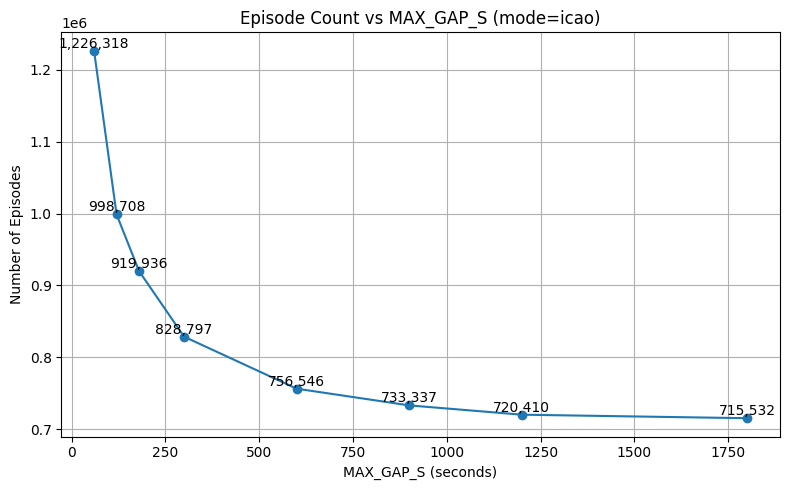

In [395]:
THRESHOLDS = np.array([60,120,180,300,600,900,1200,1800], dtype=np.int32)
MODE = "icao"
TS_COL = "point_timestamp"

required = [TS_COL, MODE]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Eksik kolon(lar): {missing}. df.columns={list(df.columns)}")

df = df.copy()
df[TS_COL] = pd.to_datetime(df[TS_COL], utc=True, errors="coerce")
df = df.dropna(subset=[MODE, TS_COL]).copy()

df = df.sort_values([MODE, TS_COL], kind="mergesort").reset_index(drop=True)

dt = df.groupby(MODE, sort=False)[TS_COL].diff().dt.total_seconds()

dt = dt.astype("float32")

base_episodes = int(df[MODE].nunique())

# =========================
# COUNT EPISODES FOR EACH THRESHOLD
# =========================
episode_counts = []
for th in THRESHOLDS:
    cuts = (dt > th)  # grup içinde gap varsa yeni episode
    n_episodes = base_episodes + int(cuts.sum())
    episode_counts.append(n_episodes)

episode_counts = np.array(episode_counts, dtype=np.int64)

# =========================
# RESULT TABLE
# =========================
res = pd.DataFrame({
    "MAX_GAP_S": THRESHOLDS,
    "n_episodes": episode_counts
})

print(res)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5))
plt.plot(THRESHOLDS, episode_counts, marker="o")
plt.xlabel("MAX_GAP_S (seconds)")
plt.ylabel("Number of Episodes")
plt.title(f"Episode Count vs MAX_GAP_S (mode={MODE})")
plt.grid(True)

for x, y in zip(THRESHOLDS, episode_counts):
    plt.text(int(x), int(y), f"{int(y):,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [396]:
MAX_GAP_S = 600

df = df.copy()
df["point_timestamp"] = pd.to_datetime(df["point_timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["icao", "point_timestamp"]).copy()

df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

df["dt_s"] = (
    df.groupby("icao")["point_timestamp"]
      .diff().dt.total_seconds().fillna(0)
)

df["episode_start"] = df["dt_s"].gt(MAX_GAP_S)
df["episode_id"] = df.groupby("icao")["episode_start"].cumsum().astype("int32")
df["flight_id"] = df["icao"].astype(str) + "_" + df["episode_id"].astype(str)

In [397]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)
flight_stats["dur_s"] = (flight_stats["t_end"] - flight_stats["t_start"]).dt.total_seconds()

print(flight_stats["n_points"].describe())
print(30*"*")
print(flight_stats["dur_s"].describe())

count    756546.000000
mean         40.501224
std          36.990951
min           1.000000
25%          13.000000
50%          31.000000
75%          58.000000
max        7678.000000
Name: n_points, dtype: float64
******************************
count    756546.000000
mean        425.702408
std         360.554520
min           0.000000
25%         138.000000
50%         328.000000
75%         673.000000
max       22683.000000
Name: dur_s, dtype: float64


## Flight Filtering

In [398]:
flight_stats.describe()

,n_points,dur_s
count,756546.000000,756546.000000
mean,40.501224,425.702408
std,36.990951,360.554520
min,1.000000,0.000000
25%,13.000000,138.000000
50%,31.000000,328.000000
75%,58.000000,673.000000
max,7678.000000,22683.000000


In [399]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()

TOTAL = len(flight_stats)

flight_stats.describe(np.arange(0.1,0.9,0.05))

,n_points,dur_s
count,756546.000000,756546.000000
mean,40.501224,425.702408
std,36.990951,360.554520
min,1.000000,0.000000
10%,5.000000,48.000000
15%,8.000000,78.000000
20%,10.000000,107.000000
25%,13.000000,138.000000
30%,16.000000,171.000000
35%,19.000000,208.000000


BEFORE FILTERING
  Total episodes : 756,546

  n_points distribution:
    p  0:      1.0
    p 10:      5.0
    p 25:     13.0
    p 50:     31.0
    p 75:     58.0
    p 90:     90.0
    p 95:    109.0
    p 99:    148.0
    p100:   7678.0

  dur_s distribution (seconds):
    p  0:      0.0
    p 10:     48.0
    p 25:    138.0
    p 50:    328.0
    p 75:    673.0
    p 90:    890.0
    p 95:   1031.8
    p 99:   1430.0
    p100:  22683.0

FILTER: drop episodes with n_points < 3
  Dropped : 36,847  (4.870%)
  Kept    : 719,699  (95.130%)

  Dropped episodes n_points distribution:
    p  0:      1.0
    p 25:      1.0
    p 50:      2.0
    p 75:      2.0
    p100:      2.0

AFTER FILTERING

  n_points distribution:
    p  0:      3.0
    p 10:      7.0
    p 25:     15.0
    p 50:     34.0
    p 75:     60.0
    p 90:     91.0
    p 95:    110.0
    p 99:    149.0
    p100:   7678.0

  dur_s distribution (seconds):
    p  0:      2.0
    p 10:     73.0
    p 25:    162.0
    p 50:   

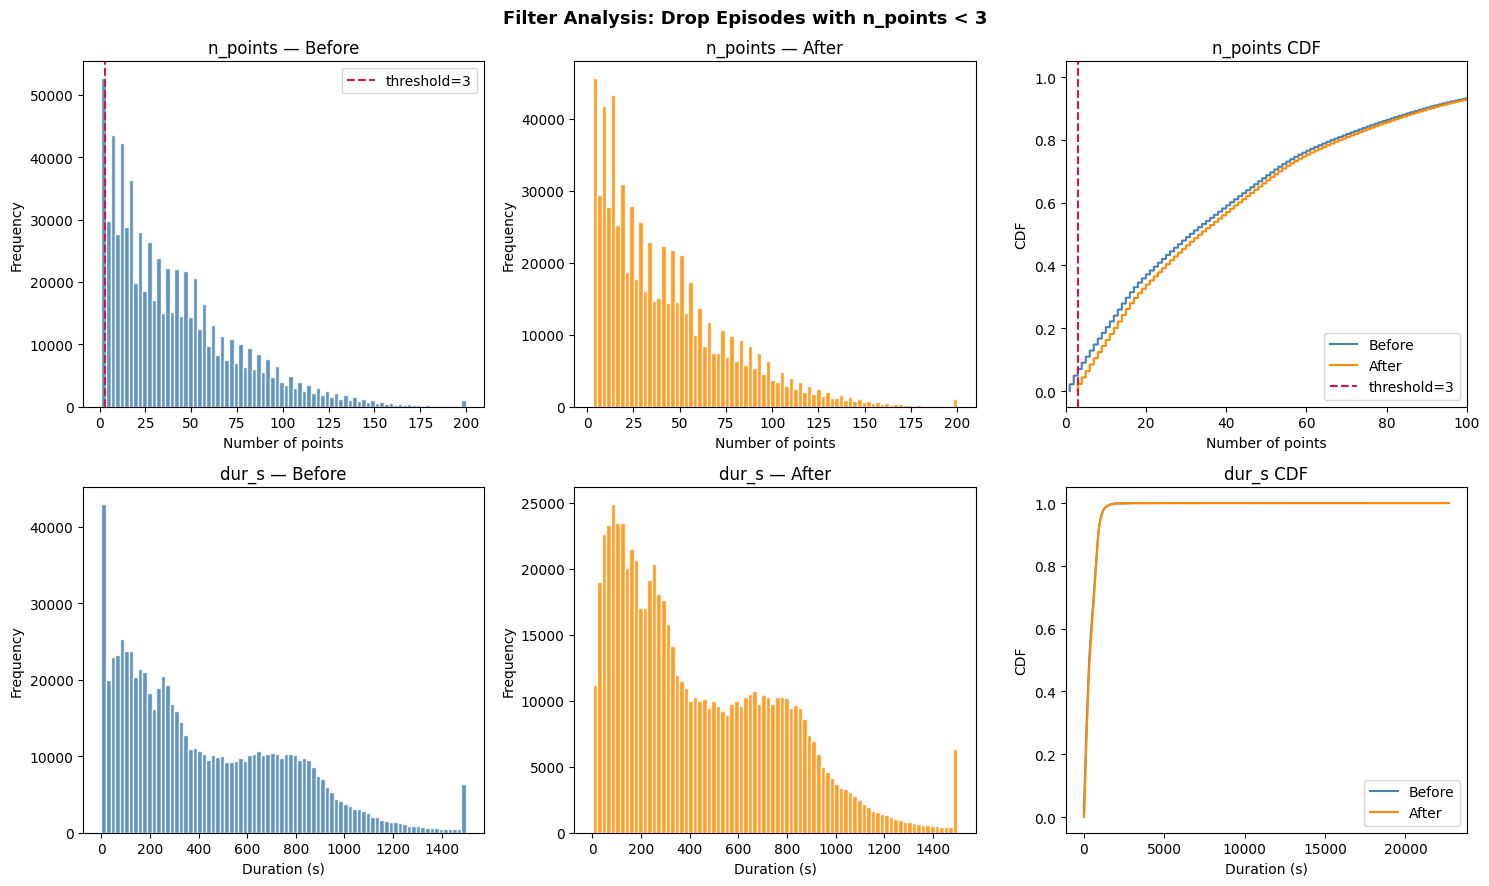

In [400]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Flight-level statistics
# ============================================================
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp", "size"),
    t_start=("point_timestamp", "min"),
    t_end=("point_timestamp", "max"),
)
flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()

TOTAL   = len(flight_stats)
MIN_PTS = 3

# ============================================================
# Apply filter
# ============================================================
bad_mask = flight_stats["n_points"] < MIN_PTS
kept     = flight_stats[~bad_mask]
dropped  = flight_stats[bad_mask]

# ============================================================
# Console summary
# ============================================================
print("=" * 55)
print("BEFORE FILTERING")
print("=" * 55)
print(f"  Total episodes : {TOTAL:,}")
print(f"\n  n_points distribution:")
for p in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"    p{p:3d}: {np.percentile(flight_stats['n_points'], p):8.1f}")
print(f"\n  dur_s distribution (seconds):")
for p in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"    p{p:3d}: {np.percentile(flight_stats['dur_s'], p):8.1f}")

print("\n" + "=" * 55)
print(f"FILTER: drop episodes with n_points < {MIN_PTS}")
print("=" * 55)
print(f"  Dropped : {bad_mask.sum():,}  ({bad_mask.mean()*100:.3f}%)")
print(f"  Kept    : {(~bad_mask).sum():,}  ({(~bad_mask).mean()*100:.3f}%)")
print(f"\n  Dropped episodes n_points distribution:")
if len(dropped):
    for p in [0, 25, 50, 75, 100]:
        print(f"    p{p:3d}: {np.percentile(dropped['n_points'], p):8.1f}")

print("\n" + "=" * 55)
print("AFTER FILTERING")
print("=" * 55)
print(f"\n  n_points distribution:")
for p in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"    p{p:3d}: {np.percentile(kept['n_points'], p):8.1f}")
print(f"\n  dur_s distribution (seconds):")
for p in [0, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"    p{p:3d}: {np.percentile(kept['dur_s'], p):8.1f}")

# ============================================================
# Visualization
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Filter Analysis: Drop Episodes with n_points < 3",
             fontsize=13, fontweight="bold")

CLIP_PTS = 200
CLIP_DUR = 1500
BINS     = 80
C_BEFORE = "steelblue"
C_AFTER  = "darkorange"
C_DROP   = "crimson"

# --- n_points histogram before ---
ax = axes[0, 0]
ax.hist(flight_stats["n_points"].clip(upper=CLIP_PTS), bins=BINS,
        color=C_BEFORE, edgecolor="white", alpha=0.85)
ax.axvline(MIN_PTS, color=C_DROP, linestyle="--", linewidth=1.5, label=f"threshold={MIN_PTS}")
ax.set_title("n_points — Before")
ax.set_xlabel("Number of points"); ax.set_ylabel("Frequency")
ax.legend()

# --- n_points histogram after ---
ax = axes[0, 1]
ax.hist(kept["n_points"].clip(upper=CLIP_PTS), bins=BINS,
        color=C_AFTER, edgecolor="white", alpha=0.85)
ax.set_title("n_points — After")
ax.set_xlabel("Number of points"); ax.set_ylabel("Frequency")

# --- n_points CDF before vs after ---
ax = axes[0, 2]
s_before = np.sort(flight_stats["n_points"])
s_after  = np.sort(kept["n_points"])
ax.plot(s_before, np.linspace(0, 1, len(s_before)), color=C_BEFORE, label="Before")
ax.plot(s_after,  np.linspace(0, 1, len(s_after)),  color=C_AFTER,  label="After")
ax.axvline(MIN_PTS, color=C_DROP, linestyle="--", linewidth=1.5, label=f"threshold={MIN_PTS}")
ax.set_xlim(0, 100)
ax.set_title("n_points CDF")
ax.set_xlabel("Number of points"); ax.set_ylabel("CDF")
ax.legend()

# --- dur_s histogram before ---
ax = axes[1, 0]
ax.hist(flight_stats["dur_s"].clip(upper=CLIP_DUR), bins=BINS,
        color=C_BEFORE, edgecolor="white", alpha=0.85)
ax.set_title("dur_s — Before")
ax.set_xlabel("Duration (s)"); ax.set_ylabel("Frequency")

# --- dur_s histogram after ---
ax = axes[1, 1]
ax.hist(kept["dur_s"].clip(upper=CLIP_DUR), bins=BINS,
        color=C_AFTER, edgecolor="white", alpha=0.85)
ax.set_title("dur_s — After")
ax.set_xlabel("Duration (s)"); ax.set_ylabel("Frequency")

# --- dur_s CDF before vs after ---
ax = axes[1, 2]
d_before = np.sort(flight_stats["dur_s"])
d_after  = np.sort(kept["dur_s"])
ax.plot(d_before, np.linspace(0, 1, len(d_before)), color=C_BEFORE, label="Before")
ax.plot(d_after,  np.linspace(0, 1, len(d_after)),  color=C_AFTER,  label="After")
ax.set_title("dur_s CDF")
ax.set_xlabel("Duration (s)"); ax.set_ylabel("CDF")
ax.legend()

plt.tight_layout()

plt.show()


In [401]:
valid_flight_ids = (
    df.groupby("flight_id")["point_timestamp"]
    .count()
    .loc[lambda x: x >= 3]
    .index
)

df_filtered = df[df["flight_id"].isin(valid_flight_ids)]

df = df_filtered.reset_index(drop=True)

In [402]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()

print(flight_stats.describe())

           n_points          dur_s
count  719699.00000  719699.000000
mean       42.49463     446.964109
std        36.83457     356.802931
min         3.00000       2.000000
25%        15.00000     162.000000
50%        34.00000     355.000000
75%        60.00000     690.000000
max      7678.00000   22683.000000


In [403]:
flight_stats = df.groupby("flight_id").agg(
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()


bad_ids = flight_stats.loc[flight_stats["dur_s"] <= 2].index

df = df[~df["flight_id"].isin(bad_ids)].copy()

print("Removed flight:", len(bad_ids))
print("Final flight count:", df["flight_id"].nunique())

Removed flight: 133
Final flight count: 719566


In [404]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()

print("="*40)
print("n_points describe")
print(flight_stats["n_points"].describe(percentiles=[.01,.05,.1,.2,.25,.5,.75,.9,.95,.99]))

print("\n"+"="*40)
print("dur_s describe")
print(flight_stats["dur_s"].describe(percentiles=[.01,.05,.1,.2,.25,.5,.75,.9,.95,.99]))

n_points describe
count    719566.00000
mean         42.50193
std          36.83406
min           3.00000
1%            3.00000
5%            5.00000
10%           7.00000
20%          12.00000
25%          15.00000
50%          34.00000
75%          60.00000
90%          91.00000
95%         110.00000
99%         149.00000
max        7678.00000
Name: n_points, dtype: float64

dur_s describe
count    719566.000000
mean        447.046353
std         356.784613
min           3.000000
1%           16.000000
5%           45.000000
10%          74.000000
20%         130.000000
25%         162.000000
50%         355.000000
75%         690.000000
90%         899.000000
95%        1042.000000
99%        1446.000000
max       22683.000000
Name: dur_s, dtype: float64


In [405]:
(flight_stats["dur_s"] > 5000).sum()

np.int64(78)

In [406]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()

MIN_PTS = 10
MIN_DUR = 60

valid_ids = flight_stats.query(
    "n_points >= @MIN_PTS and dur_s >= @MIN_DUR"
).index

df = df[df["flight_id"].isin(valid_ids)].copy()

print("Final flight count:", df["flight_id"].nunique())

Final flight count: 609525


In [407]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)

flight_stats["dur_s"] = (
    flight_stats["t_end"] - flight_stats["t_start"]
).dt.total_seconds()

print("="*40)
print("n_points describe")
print(flight_stats["n_points"].describe(percentiles=[.01,.05,.1,.2,.25,.5,.75,.9,.95,.99]))

print("\n"+"="*40)
print("dur_s describe")
print(flight_stats["dur_s"].describe(percentiles=[.01,.05,.1,.2,.25,.5,.75,.9,.95,.99]))

n_points describe
count    609525.000000
mean         48.992146
std          36.386164
min          10.000000
1%           10.000000
5%           12.000000
10%          14.000000
20%          19.000000
25%          22.000000
50%          41.000000
75%          67.000000
90%          96.000000
95%         114.000000
99%         152.000000
max        7678.000000
Name: n_points, dtype: float64

dur_s describe
count    609525.000000
mean        511.313846
std         348.346627
min          60.000000
1%           73.000000
5%          107.000000
10%         140.000000
20%         202.000000
25%         237.000000
50%         448.000000
75%         740.000000
90%         931.000000
95%        1076.000000
99%        1493.000000
max       22683.000000
Name: dur_s, dtype: float64


In [408]:
len(df)

29861938

In [374]:
len(df)

29848100

In [ ]:
import numpy as np
import pandas as pd

TIME_COL = "point_timestamp"

def episode_gap_qc(df: pd.DataFrame, max_rows=None) -> pd.DataFrame:
    """
    Episode (flight_id,episode_id) bazlı:
      - n_points
      - dur_s
      - dt_s percentiles (p50,p75,p90,p95,p99)
      - max_dt
      - share_dt_le_20, le_30
      - n_gaps_gt_20, gt_30, gt_60, gt_120
    """
    keys = ["flight_id", "episode_id"] if "episode_id" in df.columns else ["flight_id"]

    use = df[keys + [TIME_COL]].copy()
    use[TIME_COL] = pd.to_datetime(use[TIME_COL], utc=True, errors="coerce")
    use = use.dropna(subset=keys + [TIME_COL])

    if max_rows is not None and len(use) > max_rows:
        use = use.sample(max_rows, random_state=42)

    use = use.sort_values(keys + [TIME_COL])
    use["dt_s"] = use.groupby(keys)[TIME_COL].diff().dt.total_seconds()

    # episode-level aggregates
    g = use.groupby(keys, sort=False)

    def pct(s, p):
        s = s.dropna().values
        return float(np.percentile(s, p)) if len(s) else np.nan

    qc = g.agg(
        n_points=(TIME_COL, "size"),
        t_start=(TIME_COL, "min"),
        t_end=(TIME_COL, "max"),
        dt_count=("dt_s", lambda s: int(s.notna().sum())),
        max_dt=("dt_s", "max"),
        mean_dt=("dt_s", "mean"),
        share_dt_le_20=("dt_s", lambda s: float((s <= 20).mean())),
        share_dt_le_30=("dt_s", lambda s: float((s <= 30).mean())),
        n_gaps_gt_20=("dt_s", lambda s: int((s > 20).sum())),
        n_gaps_gt_30=("dt_s", lambda s: int((s > 30).sum())),
        n_gaps_gt_60=("dt_s", lambda s: int((s > 60).sum())),
        n_gaps_gt_120=("dt_s", lambda s: int((s > 120).sum())),
    ).reset_index()

    qc["dur_s"] = (qc["t_end"] - qc["t_start"]).dt.total_seconds()


    pcols = {}
    for p in [50, 75, 90, 95, 99]:
        pcols[f"p{p}_dt"] = g["dt_s"].apply(lambda s, pp=p: pct(s, pp)).values
    for k, v in pcols.items():
        qc[k] = v

    return qc


def print_episode_gap_summary(qc: pd.DataFrame):
    n = len(qc)
    print("=" * 60)
    print(f"Episodes: {n:,}")
    print("=" * 60)

    for metric, thr in [("p90_dt", 30), ("p95_dt", 30), ("max_dt", 30), ("max_dt", 60), ("max_dt", 120)]:
        rate = (qc[metric] <= thr).mean()
        print(f"{metric} <= {thr:>3}s : {rate*100:6.2f}%")

    print("\nshare_dt_le_20 distribution:")
    print(qc["share_dt_le_20"].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

    print("\nmax_dt distribution (s):")
    print(qc["max_dt"].describe(percentiles=[.5,.75,.9,.95,.99]))

    print("\ndur_s distribution (s):")
    print(qc["dur_s"].describe(percentiles=[.5,.75,.9,.95,.99]))

In [413]:
qc = episode_gap_qc(df)
print_episode_gap_summary(qc)

# En problemli episodları görmek:
qc.sort_values("max_dt", ascending=False).head(20)

Episodes: 609,525
p90_dt <=  30s :  92.12%
p95_dt <=  30s :  77.17%
max_dt <=  30s :  34.90%
max_dt <=  60s :  54.96%
max_dt <= 120s :  70.33%

share_dt_le_20 distribution:
count    609525.000000
mean          0.909083
std           0.074395
min           0.000000
1%            0.636364
5%            0.760000
10%           0.813953
25%           0.882353
50%           0.931034
75%           0.960000
90%           0.976190
95%           0.982143
99%           0.989011
max           0.999227
Name: share_dt_le_20, dtype: float64

max_dt distribution (s):
count    609525.000000
mean        110.782147
std         127.403401
min           2.000000
50%          50.000000
75%         154.000000
90%         306.000000
95%         396.000000
99%         543.000000
max         600.000000
Name: max_dt, dtype: float64

dur_s distribution (s):
count    609525.000000
mean        511.313846
std         348.346627
min          60.000000
50%         448.000000
75%         740.000000
90%         931.0000

,flight_id,episode_id,n_points,t_start,t_end,dt_count,max_dt,mean_dt,share_dt_le_20,share_dt_le_30,n_gaps_gt_20,n_gaps_gt_30,n_gaps_gt_60,n_gaps_gt_120,dur_s,p50_dt,p75_dt,p90_dt,p95_dt,p99_dt
444054,4bc849_981,981,34,2026-01-03 06:54:58+00:00,2026-01-03 07:11:26+00:00,33,600.0,29.939394,0.852941,0.911765,4,2,2,1,988.0,7.0,11.00,26.4,59.20,440.96
415053,4bb722_220,220,51,2025-12-01 13:27:07+00:00,2025-12-01 13:46:13+00:00,50,600.0,22.920000,0.843137,0.882353,7,5,2,1,1146.0,6.0,11.50,29.3,40.10,355.98
474449,4bc8c8_470,470,32,2025-07-04 16:40:37+00:00,2025-07-04 17:02:22+00:00,31,600.0,42.096774,0.812500,0.906250,5,2,2,2,1305.0,10.0,12.50,29.0,208.00,535.80
317569,4bb072_737,737,30,2025-12-18 20:13:50+00:00,2025-12-18 20:33:36+00:00,29,600.0,40.896552,0.700000,0.766667,8,6,3,1,1186.0,11.0,21.00,64.6,107.80,463.08
387227,4bb283_1087,1087,32,2025-12-27 13:15:17+00:00,2025-12-27 13:34:01+00:00,31,600.0,36.258065,0.781250,0.812500,6,5,3,1,1124.0,9.0,16.50,60.0,98.50,451.50
82735,4a34e6_0,0,24,2025-06-27 06:54:26+00:00,2025-06-27 07:11:05+00:00,23,600.0,43.434783,0.833333,0.833333,3,3,2,2,999.0,4.0,7.50,30.6,253.70,529.16
61891,488e09_5,5,143,2025-05-30 09:43:11+00:00,2025-05-30 10:14:17+00:00,142,600.0,13.140845,0.958042,0.972028,5,3,2,2,1866.0,3.0,7.00,16.0,19.00,324.33
605754,a06a7e_0,0,62,2025-03-09 03:12:53+00:00,2025-03-09 03:32:20+00:00,61,600.0,19.131148,0.935484,0.951613,3,2,2,1,1167.0,6.0,10.00,19.0,20.00,293.40
301902,4bb026_57,57,106,2025-03-21 14:40:22+00:00,2025-03-21 15:08:00+00:00,105,600.0,15.790476,0.933962,0.962264,6,3,3,2,1658.0,6.0,12.00,17.6,23.20,207.96
541614,504e84_200,200,29,2025-12-15 06:07:51+00:00,2025-12-15 06:22:00+00:00,28,600.0,30.321429,0.862069,0.896552,3,2,1,1,849.0,7.0,12.25,19.6,28.80,446.91


In [414]:
import numpy as np
import pandas as pd

TIME_COL = "point_timestamp"

def analyze_keep_after_interp20_dropnan(df: pd.DataFrame, max_fill_s: int = 20, min_keep_points: int = 30):
    """
    1Hz'e çekip (grid) sadece gap<=20 ise doldurup, kalan NaN saniyeleri sildiğinde
    episode başına kaç nokta kalır? (tahmini ama çok yakın ve hızlı)

    Varsayım: timestamp'ler saniye çözünürlüğünde veya yakın.
    Kural: iki ardışık gözlem arası dt_s = d ise aradaki eksik saniye sayısı m = round(d)-1.
           - m <= 20  => o m saniye doldurulabilir (kept)
           - m >  20  => doldurulamaz; o m saniye NaN kalır ve drop edilince gider (lost)
    """

    keys = ["flight_id", "episode_id"] if "episode_id" in df.columns else ["flight_id"]

    # sadece gerekli kolonlar
    use = df[keys + [TIME_COL]].copy()
    use[TIME_COL] = pd.to_datetime(use[TIME_COL], utc=True, errors="coerce")
    use = use.dropna(subset=keys + [TIME_COL]).sort_values(keys + [TIME_COL])

    # dt_s episode içinde
    dt = use.groupby(keys)[TIME_COL].diff().dt.total_seconds()

    # saniyeye yuvarla (timestamp genelde saniye çözünürlüklü)
    dt_i = dt.round().clip(lower=0).astype("Int64")

    # eksik saniye sayısı: dt-1 (dt=1 => 0 eksik)
    missing = (dt_i - 1).clip(lower=0)  # Int64

    # doldurulabilir / doldurulamaz
    fillable = missing.where(missing <= max_fill_s, 0)   # m<=20 ise m, yoksa 0
    unfillable = missing.where(missing >  max_fill_s, 0) # m>20 ise m, yoksa 0

    tmp = use.copy()
    tmp["missing_s"] = missing.values
    tmp["fillable_s"] = fillable.values
    tmp["unfillable_s"] = unfillable.values
    tmp["dt_s"] = dt.values

    # episode-level ham stats
    g = tmp.groupby(keys, sort=False)
    qc = g.agg(
        raw_points=(TIME_COL, "size"),
        t_start=(TIME_COL, "min"),
        t_end=(TIME_COL, "max"),
        gaps=(TIME_COL, lambda s: max(len(s)-1, 0)),
        sum_fillable_s=("fillable_s", "sum"),
        sum_unfillable_s=("unfillable_s", "sum"),
        max_dt_s=("dt_s", "max"),
        n_gaps_gt20=("unfillable_s", lambda s: int((s > 0).sum())),
    ).reset_index()

    qc["dur_s"] = (qc["t_end"] - qc["t_start"]).dt.total_seconds().astype(float)

    # 1Hz grid teorik uzunluk (start..end dahil)
    qc["grid_len_1hz"] = (qc["dur_s"].round().clip(lower=0).astype(int) + 1)

    # dropNaN sonrası kalan nokta sayısı tahmini:
    # - gözlem noktaları (raw_points) + doldurulabilen saniyeler (sum_fillable_s)
    qc["kept_points_est"] = (qc["raw_points"] + qc["sum_fillable_s"]).astype(int)

    # dropNaN ile gidecek saniyeler tahmini:
    qc["lost_points_est"] = qc["sum_unfillable_s"].astype(int)

    # kept ratio (grid'e göre)
    qc["kept_ratio_est"] = qc["kept_points_est"] / qc["grid_len_1hz"].clip(lower=1)

    # kept flag
    qc["kept_episode"] = qc["kept_points_est"] >= int(min_keep_points)

    # flight-level kept: en az 1 episode kept
    flights_total = qc["flight_id"].nunique()
    flights_kept = qc.loc[qc["kept_episode"], "flight_id"].nunique()

    summary = {
        "episodes_total": int(len(qc)),
        "episodes_kept": int(qc["kept_episode"].sum()),
        "episodes_kept_pct": float(qc["kept_episode"].mean() * 100),
        "flights_total": int(flights_total),
        "flights_kept": int(flights_kept),
        "flights_kept_pct": float((flights_kept / max(flights_total, 1)) * 100),
        "total_raw_points": int(qc["raw_points"].sum()),
        "total_fillable_seconds": int(qc["sum_fillable_s"].sum()),
        "total_unfillable_seconds": int(qc["sum_unfillable_s"].sum()),
        "total_kept_points_est": int(qc["kept_points_est"].sum()),
        "total_grid_len_1hz_est": int(qc["grid_len_1hz"].sum()),
        "overall_kept_ratio_est": float(qc["kept_points_est"].sum() / max(qc["grid_len_1hz"].sum(), 1)),
    }

    return qc, summary

In [415]:
qc, summary = analyze_keep_after_interp20_dropnan(df, max_fill_s=20, min_keep_points=30)

print(summary)

# Kalacak episode uzunlukları:
print(qc.loc[qc["kept_episode"], "kept_points_est"].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

# En kötü gap yapan episodlar:
print(qc.sort_values(["sum_unfillable_s","max_dt_s"], ascending=False).head(20))

{'episodes_total': 609525, 'episodes_kept': 608203, 'episodes_kept_pct': 99.78310979861368, 'flights_total': 609525, 'flights_kept': 608203, 'flights_kept_pct': 99.78310979861368, 'total_raw_points': 29861938, 'total_fillable_seconds': 176348689, 'total_unfillable_seconds': 106057470, 'total_kept_points_est': 206210627, 'total_grid_len_1hz_est': 312268097, 'overall_kept_ratio_est': 0.6603640556979473}
count    608203.000000
mean        338.999028
std         222.600017
min          30.000000
1%           50.000000
5%           77.000000
10%          98.000000
25%         162.000000
50%         288.000000
75%         477.000000
90%         664.000000
95%         764.000000
99%         906.000000
max       22082.000000
Name: kept_points_est, dtype: float64
         flight_id  episode_id  raw_points                   t_start  \
89131     4b858e_0           0         365 2025-03-05 06:29:05+00:00   
25919    32b405_11          11         566 2025-12-30 09:40:42+00:00   
22591     151fa5_2 

In [416]:
# kept_ratio < 0.30 olan flight'ları bul
bad_ratio = qc[qc["kept_ratio_est"] < 0.30]["flight_id"].unique()
good_ratio = qc[qc["kept_ratio_est"] >= 0.30]["flight_id"].unique()

print(f"Silinecek flight : {len(bad_ratio):>8,} ({len(bad_ratio)/len(qc)*100:.1f}%)")
print(f"Kalacak flight   : {len(good_ratio):>8,} ({len(good_ratio)/len(qc)*100:.1f}%)")

# Kalacak flight'ların kept_points_est dağılımı
print("\nKalacak flight nokta sayısı:")
print(qc.loc[qc["kept_ratio_est"] >= 0.30, "kept_points_est"].describe(
    percentiles=[.1,.25,.5,.75,.9,.95,.99]
))

# Farklı threshold'ları dene
print("\nThreshold karşılaştırması:")
for t in [0.10, 0.20, 0.30, 0.40, 0.50]:
    n = (qc["kept_ratio_est"] >= t).sum()
    print(f"  ≥{int(t*100)}% dolu: {n:>8,} flight ({n/len(qc)*100:.1f}%)")

Silinecek flight :   42,734 (7.0%)
Kalacak flight   :  566,791 (93.0%)

Kalacak flight nokta sayısı:
count    566791.000000
mean        352.401894
std         222.913579
min          20.000000
10%         105.000000
25%         175.000000
50%         305.000000
75%         493.000000
90%         675.000000
95%         772.000000
99%         910.000000
max       22082.000000
Name: kept_points_est, dtype: float64

Threshold karşılaştırması:
  ≥10% dolu:  606,661 flight (99.5%)
  ≥20% dolu:  592,747 flight (97.2%)
  ≥30% dolu:  566,791 flight (93.0%)
  ≥40% dolu:  527,807 flight (86.6%)
  ≥50% dolu:  478,702 flight (78.5%)


In [ ]:
# Ham veriden kept_ratio hesapla
flight_filter = qc[qc["kept_ratio_est"] >= 0.30]["flight_id"].unique()


df_clean = df[df["flight_id"].isin(flight_filter)].copy()

print(f"Öncesi: {df['flight_id'].nunique():,} flight, {len(df):,} satır")
print(f"Sonrası: {df_clean['flight_id'].nunique():,} flight, {len(df_clean):,} satır")

Öncesi: 609,525 flight, 29,861,938 satır
Sonrası: 566,791 flight, 28,425,192 satır


In [418]:
print(df["flight_id"].head(5).tolist())
print("Unique flight_id:", df["flight_id"].nunique())
print("Unique episode_id:", df["episode_id"].nunique())

['000001_0', '000001_0', '000001_0', '000001_0', '000001_0']
Unique flight_id: 609525
Unique episode_id: 1756


In [419]:
qc_f = qc[qc["kept_ratio_est"] >= 0.30]
qc_f["kept_points_est"].sum()

np.int64(199738222)

In [426]:
flight_filter = qc.loc[qc["kept_ratio_est"] >= 0.30, "flight_id"].unique()
df_clean = df[df["flight_id"].isin(flight_filter)].copy()

In [427]:
df = df_clean

In [428]:
dt = (
    df
    .groupby("flight_id", sort=False)["point_timestamp"]
    .diff()
    .dt.total_seconds()
)

print(dt.describe(percentiles=[.5,.75,.9,.95,.99]))
print("Negative dt:", (dt < 0).sum())

count    2.785840e+07
mean     1.007276e+01
std      2.192425e+01
min      1.000000e+00
50%      6.000000e+00
75%      1.200000e+01
90%      1.900000e+01
95%      2.000000e+01
99%      7.400000e+01
max      6.000000e+02
Name: point_timestamp, dtype: float64
Negative dt: 0


## ENU Coordinate Transformation

In [429]:
import pymap3d as pm

In [430]:
LAT = 41.275278
LON = 28.751944
H0_M = 99.0

def add_enu_pymap3d(df, lat0=LAT, lon0=LON, h0_m=H0_M,
                    lat_col="latitude", lon_col="longitude", alt_ft_col="altitude_baro"):

    lat = df[lat_col].to_numpy(dtype=np.float64)
    lon = df[lon_col].to_numpy(dtype=np.float64)


    h_m = (df[alt_ft_col].to_numpy(dtype=np.float64) * 0.3048)

    # ENU (meters)
    e, n, u = pm.geodetic2enu(lat, lon, h_m, lat0, lon0, h0_m, deg=True)

    df = df.copy()
    df["e_m"] = e.astype(np.float32)
    df["n_m"] = n.astype(np.float32)
    df["u_m"] = u.astype(np.float32)
    return df


df = add_enu_pymap3d(df)

## 1 sec data resampling 

In [442]:
if "dt_s" in df.columns:
    df = df.drop(columns=["dt_s"])

# Güvenli sıralama
df = df.sort_values(["flight_id", "point_timestamp"]).copy()

# Flight içi inter-point dt
df["dt_s"] = (
    df.groupby("flight_id")["point_timestamp"]
      .diff()
      .dt.total_seconds()
)

# İlk satırlar NaN olur → 0 yapalım
df["dt_s"] = df["dt_s"].fillna(0).astype("float32")

In [443]:
print("Negative dt:", int((df["dt_s"] < 0).sum()))
print("Max dt_s:", df["dt_s"].max())

Negative dt: 0
Max dt_s: 600.0


In [444]:
import numpy as np

print("="*55)
print("dt_s DISTRIBUTION (flight-level inter-point)")
print("="*55)

for p in [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f"p{p:>5}: {np.percentile(df['dt_s'], p):>8.2f}s")

print("\nMean :", df["dt_s"].mean())
print("Std  :", df["dt_s"].std())

dt_s DISTRIBUTION (flight-level inter-point)
p    0:     0.00s
p    1:     0.00s
p    5:     1.00s
p   10:     1.00s
p   25:     3.00s
p   50:     6.00s
p   75:    12.00s
p   90:    19.00s
p   95:    20.00s
p   99:    73.00s
p  100:   600.00s

Mean : 9.871915
Std  : 21.750198


In [445]:
total = len(df)
over60 = (df["dt_s"] > 60).sum()

print("dt_s > 60 count :", f"{over60:,}")
print("dt_s > 60 %     :", f"{100*over60/total:.4f}%")

dt_s > 60 count : 347,228
dt_s > 60 %     : 1.2216%


In [446]:
max_dt = df.groupby("flight_id")["dt_s"].max()

bad_flights = (max_dt > 60).sum()
total_flights = max_dt.shape[0]

print("Flights with dt>60 :", f"{bad_flights:,}")
print("Percent flights    :", f"{100*bad_flights/total_flights:.2f}%")

Flights with dt>60 : 232,588
Percent flights    : 41.04%


In [447]:
import numpy as np

# Flight içi sıra
df["seq_idx"] = df.groupby("flight_id").cumcount()

# Flight uzunluğu
flight_sizes = df.groupby("flight_id")["seq_idx"].max()

df = df.join(flight_sizes, on="flight_id", rsuffix="_max")

# Normalize edilmiş pozisyon (0 = baş, 1 = son)
df["rel_pos"] = df["seq_idx"] / df["seq_idx_max"]

# Büyük gap noktaları
gaps = df[df["dt_s"] > 60]

print("Gap sayısı:", len(gaps))
print("Median position:", gaps["rel_pos"].median())
print("p25:", gaps["rel_pos"].quantile(0.25))
print("p75:", gaps["rel_pos"].quantile(0.75))

Gap sayısı: 347228
Median position: 0.5454545454545454
p25: 0.18518518518518517
p75: 0.839622641509434


In [ ]:
import numpy as np
import pandas as pd


def to_bool_series(s: pd.Series) -> pd.Series:
    # True/False, 1/0, "1"/"0", "true"/"false"
    if s.dtype == bool:
        return s
    ss = s.astype("string").str.lower().str.strip()
    return ss.isin(["1", "true", "t", "yes", "y"])


df = df.sort_values(["flight_id", "point_timestamp"]).copy()

df["dt_s"] = (
    df.groupby("flight_id")["point_timestamp"]
      .diff()
      .dt.total_seconds()
      .fillna(0)
      .astype("float32")
)


df["on_ground_b"] = to_bool_series(df["on_ground"])


df["gap_gt20"] = df["dt_s"] > 20
df["gap_gt60"] = df["dt_s"] > 60


summary = (
    df.groupby("on_ground_b")[["gap_gt20", "gap_gt60"]]
      .mean()
      .rename(index={False: "AIR (on_ground=0)", True: "GROUND (on_ground=1)"})
)

counts = (
    df.groupby("on_ground_b")[["gap_gt20", "gap_gt60"]]
      .sum()
      .rename(index={False: "AIR (on_ground=0)", True: "GROUND (on_ground=1)"})
)

totals = (
    df.groupby("on_ground_b")
      .size()
      .rename(index={False: "AIR (on_ground=0)", True: "GROUND (on_ground=1)"})
)

print("\n=== POINT-LEVEL GAP RATES ===")
print("Totals:")
print(totals.to_string())
print("\nGap counts:")
print(counts.to_string())
print("\nGap rates (mean):")
print(summary.to_string(float_format=lambda x: f"{100*x:6.3f}%"))


flight_flags = (
    df.groupby("flight_id")
      .agg(
          any_gap_gt20=("gap_gt20", "any"),
          any_gap_gt60=("gap_gt60", "any"),

          ground_share=("on_ground_b", "mean"),
          n_points=("dt_s", "size"),
      )
)


flight_flags["mostly_ground"] = flight_flags["ground_share"] >= 0.5

flight_summary = (
    flight_flags.groupby("mostly_ground")[["any_gap_gt20", "any_gap_gt60"]]
      .mean()
      .rename(index={False: "Mostly AIR", True: "Mostly GROUND"})
)

print("\n=== FLIGHT-LEVEL: P(ANY GAP) ===")
print(flight_summary.to_string(float_format=lambda x: f"{100*x:6.2f}%"))


try:
    from scipy.stats import chi2_contingency

    def chi2_for(flag_col: str):
        ct = pd.crosstab(df["on_ground_b"], df[flag_col])
        chi2, p, dof, exp = chi2_contingency(ct.values)
        return ct, chi2, p

    for col in ["gap_gt20", "gap_gt60"]:
        ct, chi2, p = chi2_for(col)
        print(f"\n=== CHI-SQUARE: on_ground vs {col} ===")
        print(ct)
        print(f"chi2={chi2:.2f}  p-value={p:.3e}")
except Exception as e:
    print("\n(scipy yoksa chi-square kısmı atlanır) ->", repr(e))


=== POINT-LEVEL GAP RATES ===
Totals:
on_ground_b
AIR (on_ground=0)       28238794
GROUND (on_ground=1)      186398

Gap counts:
                      gap_gt20  gap_gt60
on_ground_b                             
AIR (on_ground=0)      1197649    342142
GROUND (on_ground=1)     12535      5086

Gap rates (mean):
                      gap_gt20  gap_gt60
on_ground_b                             
AIR (on_ground=0)       4.241%    1.212%
GROUND (on_ground=1)    6.725%    2.729%

=== FLIGHT-LEVEL: P(ANY GAP) ===
               any_gap_gt20  any_gap_gt60
mostly_ground                            
Mostly AIR           75.09%        40.97%
Mostly GROUND        88.44%        59.37%

=== CHI-SQUARE: on_ground vs gap_gt20 ===
gap_gt20        False    True 
on_ground_b                   
False        27041145  1197649
True           173863    12535
chi2=2801.81  p-value=0.000e+00

=== CHI-SQUARE: on_ground vs gap_gt60 ===
gap_gt60        False   True 
on_ground_b                  
False        278966